# Gradient Boosting Hyperparameter Tuning

## Notebook Objective

This notebook tunes a Gradient Boosting Regressor for monthly cost prediction using cross-validation.

The goal is to test whether hyperparameter tuning improves Gradient Boosting performance compared with the baseline Gradient Boosting model.

The tuned model is evaluated on a held-out test set using MAE, RMSE, and R².

This notebook focuses on model tuning and generalization, not causal interpretation.

## 1. Imports

In [1]:
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt 

from sklearn.model_selection import train_test_split, GridSearchCV # Split data and tune hyperparameters
from sklearn.compose import ColumnTransformer # Apply preprocessing by column type
from sklearn.preprocessing import OneHotEncoder # Encode categorical variables
from sklearn.pipeline import Pipeline # Combine preprocessing and modeling steps

from sklearn.ensemble import GradientBoostingRegressor # Main Day 16 model

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score # Regression metrics

## 2. Load Data

In [2]:
df = pd.read_csv("../data/processed/member_analysis_ready.csv")

df.head() # Preview first five rows 


,member_id,age,gender,region,plan_type,sdoh_risk_score,chronic_condition_count,engagement_score,pcp_attributed_24mo,prior_awv_count,...,engagement_group,age_group,high_cost_member,chronic_burden_group,sdoh_risk_group,prior_awv_group,total_acute_visits,acute_utilization_group,pcp_status,has_acute_utilization
0,M00001,69,Male,Suburban,Medicare Advantage,40.7,2,68.9,1,1,...,Q4_High,65-79,1,Moderate,Q1_Low,1,2,Low,Attributed,1
1,M00002,32,Female,Urban,DSNP,80.0,3,30.4,0,0,...,Q1_Low,18-34,0,Moderate,Q4_High,0,2,Low,Not Attributed,1
2,M00003,89,Female,Suburban,Medicare Advantage,49.6,3,86.3,1,3,...,Q4_High,80+,0,Moderate,Q2,3,0,NaN,Attributed,0
3,M00004,78,Male,Suburban,Medicare Advantage,45.7,4,63.1,1,1,...,Q4_High,65-79,1,High,Q1_Low,1,3,Moderate,Attributed,1
4,M00005,38,Male,Suburban,Medicare Advantage,32.4,0,55.6,0,0,...,Q4_High,35-49,0,Low,Q1_Low,0,0,NaN,Not Attributed,0


## 3. Define target and features

In [3]:
target = "monthly_cost" # Define regression target

drop_cols = [
    "member_id",              # Identifier, not a predictive feature
    target,                   # Target variable must be removed from predictors
    "high_cost_member",       # Derived from monthly_cost, causes target leakage
    "awv_completed",          # Excluded to keep cost prediction focused on risk/access/utilization

    # Full-dataset grouped/qcut features or redundant engineered features
    "engagement_group",
    "sdoh_risk_group",
    "age_group",
    "chronic_burden_group",
    "pcp_status",
    "prior_awv_group",
    "total_acute_visits",
    "acute_utilization_group",
    "has_acute_utilization",

    # Redundant with prior_awv_rate
    "prior_awv_count"
]

X = df.drop(columns=drop_cols)  # Create feature matrix
y = df[target] # Create target vector 




## Feature Selection Logic

This notebook uses the same cleaned cost-prediction feature set as the prior regression notebooks.

The model excludes `member_id`, `high_cost_member`, `awv_completed`, full-dataset grouped features, and redundant engineered variables.

`high_cost_member` is excluded because it is derived from `monthly_cost` and would create target leakage.

`awv_completed` is excluded to keep cost prediction focused on member characteristics, risk, access, engagement, and utilization.

Grouped features such as `engagement_group`, `sdoh_risk_group`, and `chronic_burden_group` are excluded because the raw source variables are already included.

Derived utilization variables such as `total_acute_visits`, `acute_utilization_group`, and `has_acute_utilization` are excluded because `ed_visits` and `ip_admits` are already included separately.

This keeps the tuned Gradient Boosting comparison consistent with the earlier cost-regression notebooks.

## 4. Detect column types

In [4]:
categorical_cols = X.select_dtypes(
    include=["object", "string", "category", "bool"]
).columns.tolist() # Identify categorical columns

numeric_cols = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist() # Identify numeric columns

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

Categorical columns: ['gender', 'region', 'plan_type']
Numeric columns: ['age', 'sdoh_risk_score', 'chronic_condition_count', 'engagement_score', 'pcp_attributed_24mo', 'prior_awv_rate', 'ed_visits', 'ip_admits']


## 5. Train/test split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,              # Feature matrix
    y,              # Target vector
    test_size=0.20, # Reserve 20% for testing
    random_state=42 # Reproducible split
)

## 6. Build preprocessing

In [6]:
preprocessor = ColumnTransformer(
    transformers = [
        ( 
                "cat",
                OneHotEncoder(drop = "first", handle_unknown="ignore"),
                categorical_cols
        )
    ],
    remainder = "passthrough" # Keep numeric columns unchanged
)

## 7. Build Gradient Boosting pipeline

In [7]:
gb_pipeline = Pipeline(
    steps = [
        ("preprocessor", preprocessor),     # Encode categorical variables 
    (
        "model",
        GradientBoostingRegressor(
            random_state=42 # Make results reproducible
            )
        ) 
    ]
)

## 8. Define hyperparameter grid

In [8]:
param_grid = {
    "model__n_estimators": [100, 200, 300],     # Number of boosting stages
    "model__learning_rate": [0.03, 0.05, 0.10], # Step size for each boosting update
    "model__max_depth": [2, 3, 4],              # Depth of each individual tree
    "model__min_samples_leaf": [5, 10, 20]      # Minimum samples required in each final leaf
}

## 9. Run GridSearchCV

## Why Tune Gradient Boosting?

Gradient Boosting performance depends heavily on hyperparameters.

The most important tuning controls are:

- `n_estimators`: number of boosting stages.
- `learning_rate`: how much each new tree contributes.
- `max_depth`: complexity of each individual tree.
- `min_samples_leaf`: minimum number of samples in a terminal leaf.

A smaller learning rate often needs more trees. Deeper trees can capture more complex patterns but may overfit.

This notebook uses `GridSearchCV` to test combinations of these settings using 5-fold cross-validation on the training data only.

In [9]:
grid_search = GridSearchCV(
    estimator=gb_pipeline,          # Pipeline to tune 
    param_grid=param_grid,          # Hyperparameter combinations
    scoring="neg_root_mean_squared_error", # Use RMSE, stored as negative by sklearn
    cv=5,                           # 5-fold cross-validation 
    n_jobs= -1,                       # Use available CPU cores
    verbose=1                       # Show tuning progress
)

grid_search.fit(X_train, y_train) # Fit only on training data

Fitting 5 folds for each of 81 candidates, totalling 405 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.03, 0.05, ...], 'model__max_depth': [2, 3, ...], 'model__min_samples_leaf': [5, 10, ...], 'model__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messa

## 10. Review best parameters

In [10]:
print("Best parameters:")
print(grid_search.best_params_)

print("Best CV RMSE:")
print(-grid_search.best_score_) # Convert negative RMSE back to positive RMSE

Best parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__min_samples_leaf': 10, 'model__n_estimators': 100}
Best CV RMSE:
528.4465174976698


## 11. Evaluate tuned model on test set

In [11]:
best_gb_model = grid_search.best_estimator_ # Extract best fitted pipeline

y_train_pred = best_gb_model.predict(X_train) # Predict training data
y_test_pred = best_gb_model.predict(X_test) # Predict test data

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

tuned_gb_results = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "MAE": [train_mae, test_mae],
    "RMSE": [train_rmse, test_rmse],
    "R2": [train_r2, test_r2]
})

tuned_gb_results


,Dataset,MAE,RMSE,R2
0,Train,297.977345,478.163484,0.855847
1,Test,374.689820,644.499294,0.770852


## Tuned Gradient Boosting Performance Interpretation

The tuned Gradient Boosting model achieved test MAE of about `$375`, test RMSE of about `$644`, and test R² of about `0.771`.

The training performance is stronger than the test performance, which is expected. The gap suggests some overfitting, but the test performance remains close to the baseline Gradient Boosting model.

The RMSE is higher than the MAE, meaning the model still has some larger errors, likely among high-cost members.

## 12. Compare baseline vs tuned Gradient Boosting

In [12]:
gb_comparison = pd.DataFrame({
    "Model": [
        "Baseline Gradient Boosting",
        "Tuned Gradient Boosting"
    ],
    "Test MAE": [
        373.47,
        test_mae
    ],
    "Test RMSE": [
        644.38,
        test_rmse
    ],
    "Test R2": [
        0.77,
        test_r2
    ]
})

gb_comparison

,Model,Test MAE,Test RMSE,Test R2
0,Baseline Gradient Boosting,373.47000,644.380000,0.770000
1,Tuned Gradient Boosting,374.68982,644.499294,0.770852


## Baseline vs Tuned Gradient Boosting Interpretation

The tuned Gradient Boosting model performed almost the same as the baseline Gradient Boosting model.

Test MAE increased slightly from about `$373` to about `$375`, and test RMSE increased slightly from about `$644.38` to about `$644.50`.

R² increased slightly from about `0.770` to about `0.771`.

These differences are extremely small and not practically meaningful.

This suggests that hyperparameter tuning did not materially improve Gradient Boosting performance in this run. The baseline Gradient Boosting settings were already reasonable for this synthetic dataset.

## 13. Actual vs Predited plot

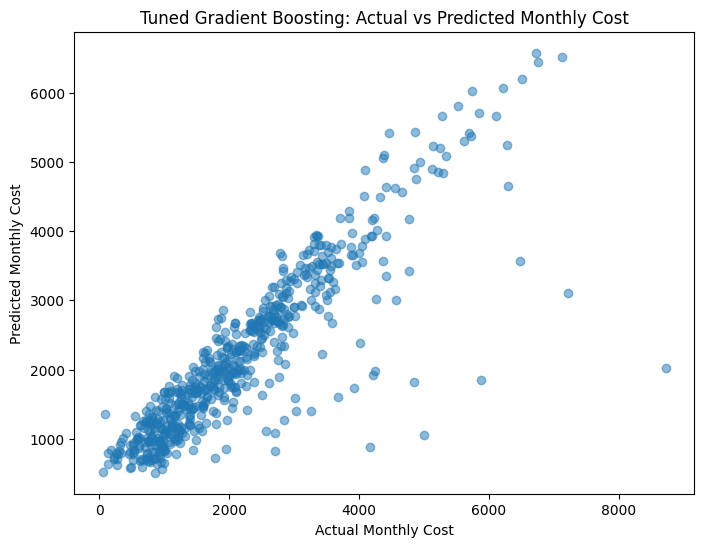

In [13]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_test_pred, alpha=0.5)

plt.xlabel("Actual Monthly Cost")
plt.ylabel("Predicted Monthly Cost")
plt.title("Tuned Gradient Boosting: Actual vs Predicted Monthly Cost")

plt.show()

## 14. Residual plot

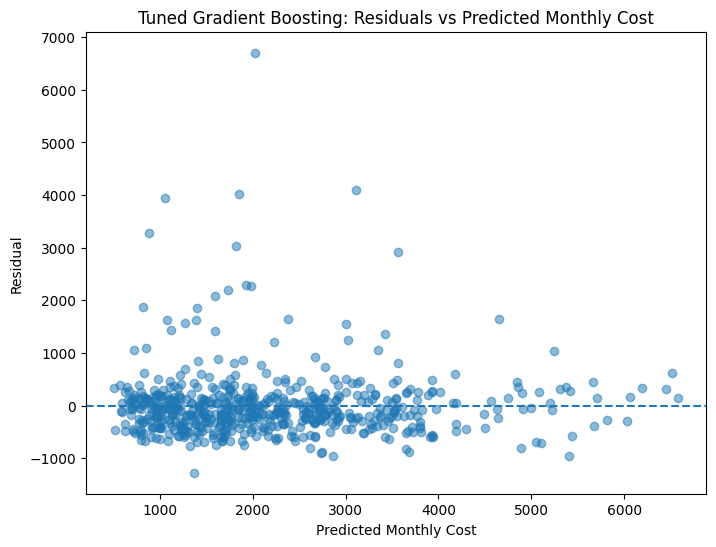

In [14]:
residuals = y_test - y_test_pred  # Actual minus predicted

plt.figure(figsize=(8, 6))

plt.scatter(y_test_pred, residuals, alpha=0.5)
plt.axhline(0, linestyle="--")

plt.xlabel("Predicted Monthly Cost")
plt.ylabel("Residual")
plt.title("Tuned Gradient Boosting: Residuals vs Predicted Monthly Cost")

plt.show()

## 15. Feature importance

In [15]:
trained_preprocessor = best_gb_model.named_steps["preprocessor"] # Access fitted preprocessor
trained_gb = best_gb_model.named_steps["model"] # Access fitted Gradient Boosting model

feature_names = trained_preprocessor.get_feature_names_out() # Get transformed feature names

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": trained_gb.feature_importances_
}).sort_values(by="importance", ascending = False)

importance_df.head(20)


,feature,importance
7,remainder__chronic_condition_count,0.541419
12,remainder__ip_admits,0.301616
11,remainder__ed_visits,0.081680
5,remainder__age,0.019848
8,remainder__engagement_score,0.018611
3,cat__plan_type_Medicaid,0.013954
4,cat__plan_type_Medicare Advantage,0.012164
6,remainder__sdoh_risk_score,0.007174
9,remainder__pcp_attributed_24mo,0.002442
2,cat__region_Urban,0.000492


## 16. Plot feature importance

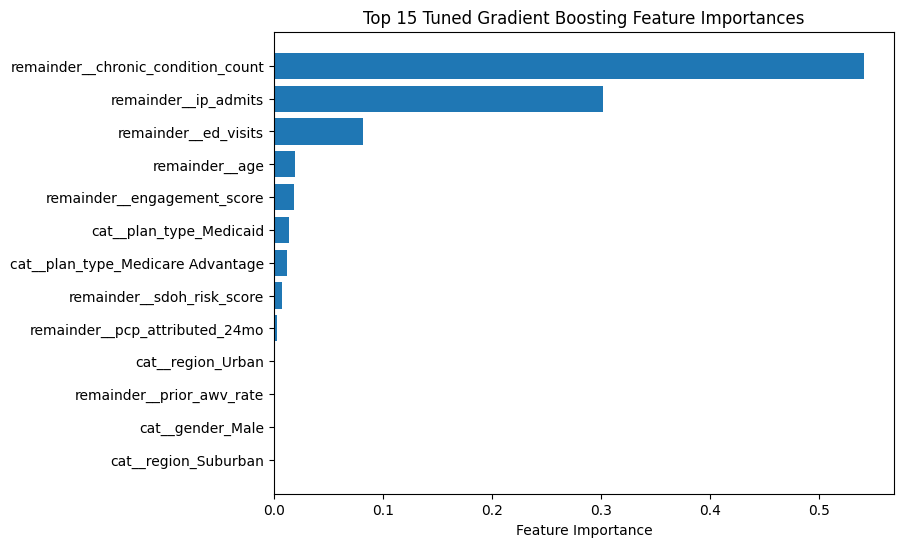

In [16]:
top_features = importance_df.head(15).sort_values(by="importance") # Sort for horizontal chart

plt.figure(figsize=(8, 6))

plt.barh(top_features["feature"], top_features["importance"])

plt.xlabel("Feature Importance")
plt.title("Top 15 Tuned Gradient Boosting Feature Importances")

plt.show()

## Feature Importance Interpretation

The tuned Gradient Boosting model relied most heavily on chronic condition count, inpatient admissions, and ED visits.

This aligns with the synthetic data-generation logic, where chronic burden and acute utilization are major drivers of monthly cost.

Feature importance measures predictive usefulness inside this fitted model. It does not prove causality.

A high-importance feature means the model used that feature to reduce prediction error, not that the feature directly causes higher cost.

## 17. Findings

This notebook tuned a Gradient Boosting Regressor for monthly cost prediction using 5-fold cross-validation.

The model used the same cleaned cost-prediction feature set as the prior regression notebooks to avoid leakage and maintain comparison consistency.

The tuning grid tested number of boosting stages, learning rate, maximum tree depth, and minimum samples per leaf.

The best model was selected using cross-validated RMSE on the training data only.

Final performance was evaluated on the held-out test set using MAE, RMSE, and R².

In this run, the tuned Gradient Boosting model did not materially improve compared with the baseline Gradient Boosting model.

The tuned model achieved test MAE of about `$375`, test RMSE of about `$644`, and test R² of about `0.771`.

Compared with the baseline Gradient Boosting model, MAE and RMSE were slightly worse while R² was slightly better. The differences were too small to be practically meaningful.

This suggests that the baseline Gradient Boosting configuration was already reasonably strong, and this tuning grid did not produce a clearly better model.

Feature importance showed that chronic condition count, inpatient admissions, and ED visits were the most important predictors in the fitted model.

Feature importance values show predictive usefulness inside the fitted model. They do not prove causal effects.

Because this project uses synthetic data, these findings reflect the data-generation assumptions rather than real-world healthcare evidence.

A logical next step is to build a final model comparison notebook across the strongest models.